# Investigation support: 0.01 versus 0.03

In [1]:
import os
import sys
from dataclasses import replace

sys.path[:0] = [os.path.abspath("scripts"), os.path.abspath(".."), os.path.abspath("../differential_rules")]
import complex_investigation as ci
import complex_investigation_vis as vis
import complex_hypotheses as hypotheses
from IPython.display import display

In [2]:
CONFIG = ci.Config(
    max_items=4, support=0.01, expected_support=0.01, confidence=0.5,
    min_cells=20, min_fovs=5, min_patients=3, min_group_fovs=10,
    visible_gap=0.15, top_n=8, permutations=4999,
    score=os.environ.get("SCORE_COLUMN", "Clinical score"),
)
PREFIX = "support_" + ("clin" if CONFIG.score.startswith("Clinical") else "path")

Optional follow-up only: choose the rule list at the baseline 0.01 gates, then compare those same rules at 0.03. Mining is unchanged. At 0.03, attraction needs observed support ≥0.03; avoidance needs expected support ≥0.03. Confidence stays fixed and eligibility denominators do not change. Inspect both rendered plots; the stricter gate neither selects new findings nor removes baseline findings.

In [3]:
cells, metadata, rules = ci.load(CONFIG)
baseline = ci.analyse(rules, cells, metadata, CONFIG)
STRICT = replace(CONFIG, support=0.03, expected_support=0.03)
stricter = ci.analyse(rules, cells, metadata, STRICT)

Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71
Read results_CN_pairwise.csv + results_CN_complex.csv
{'max_items': 4, 'min_cells': 20, 'mining_fdr': 0.05, 'support': 0.01, 'confidence': 0.5, 'expected_support': 0.01, 'score': 'Clinical score', 'min_fovs': 5, 'min_patients': 3, 'min_group_fovs': 10, 'visible_gap': 0.15, 'attraction_lift_gap': 0.3, 'avoidance_lift_gap': 0.15, 'permutations': 4999, 'top_n': 8}
690,345 stored center-specific occurrences; distinct cell types only
Mining settings: {'settings': {'weighting': 'binary', 'method': 'CN', 'radius': 25.0, 'min_support': 0.01, 'min_lift': 1.2, 'max_items_per_rule': 4, 'bandwidth': 15.0, 'k_neighbors': None, 'min_cells_per_patch': 2, 'max_one_type_share': 0.9, 'min_patches': 15, 'strong_confidence': 0.9, 'min_support_when_strong': 0.005, 'min_confidence': 0.5, 'min_leverage': 0.0005, 'min_conviction': 1.3, 'include_avoidance_rules': True, 'avoidance_max_lift': 0.8, 'avoidance_max_leverage': None

In [4]:
initial = ci.candidates(baseline['counts'], baseline['tests'], CONFIG)
ci.save_tables(baseline, initial, PREFIX + '_001')
ci.save_tables(stricter, initial, PREFIX + '_003')
SPECS = initial.reset_index(drop=True)
display(SPECS)
print(f'{len(SPECS)} comparisons; add indexed cells below if you increase top_n beyond these 32 slots.')

,organ,rule,kind,gap,contrast,patient_fdr,hits,patients,eligible,share,stream
0,Colon,Goblet -> CD8T + Fibroblast + Plasma,avoids,0.630000,Control–Severe,0.350240,18,5,47,0.382979,visible
1,Colon,Goblet -> Endothelial + SMV,avoids,0.612500,Control–Severe,0.674259,17,9,34,0.500000,visible
2,Duodenum,Muscle -> Endothelial + Plasma_CD38,avoids,0.500000,Control–Severe,0.733877,14,10,56,0.250000,visible
3,Duodenum,Goblet -> Fibroblast + Neuron,avoids,0.495833,Control–Mild,0.350240,54,28,126,0.428571,visible
4,Colon,Epithelial + Fibroblast -> Plasma,attracts,0.481538,Control–Severe,0.642713,14,5,55,0.254545,visible
5,Colon,Goblet + Macrophage -> Plasma,attracts,0.480000,Control–Severe,0.674259,13,5,51,0.254902,visible
6,Duodenum,Fibroblast + Paneth -> Epithelial + Neuron,attracts,0.447552,Control–Severe,0.674259,18,11,75,0.240000,visible
7,Duodenum,Fibroblast + Paneth -> Epithelial + Macrophage,attracts,0.384615,Control–Severe,0.418765,20,16,81,0.246914,visible


8 comparisons; add indexed cells below if you increase top_n beyond these 32 slots.


In [5]:
def show_selected(index):
    vis.show_threshold(index, SPECS, baseline, stricter, metadata, PREFIX, cells)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_001_Colon_a78f846358_summary.pdf


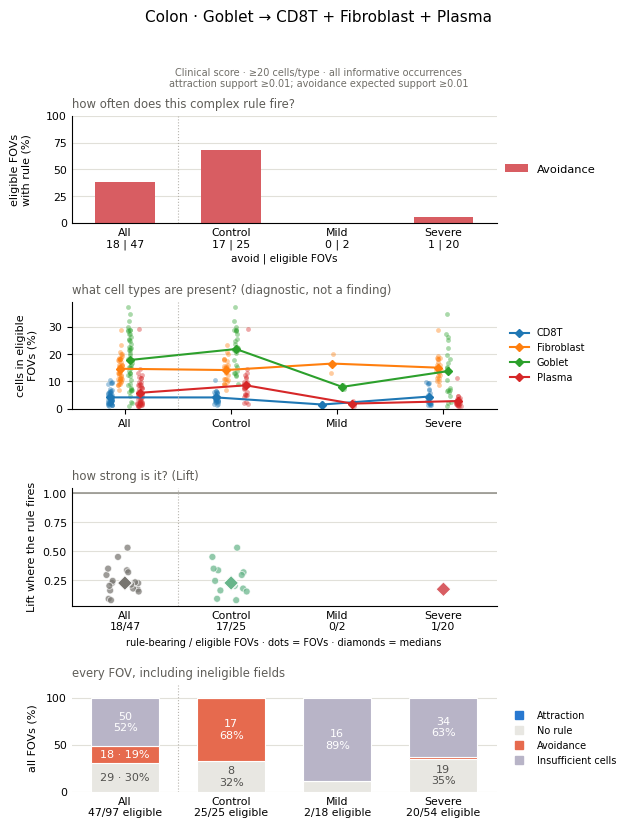

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_003_Colon_a78f846358_summary.pdf


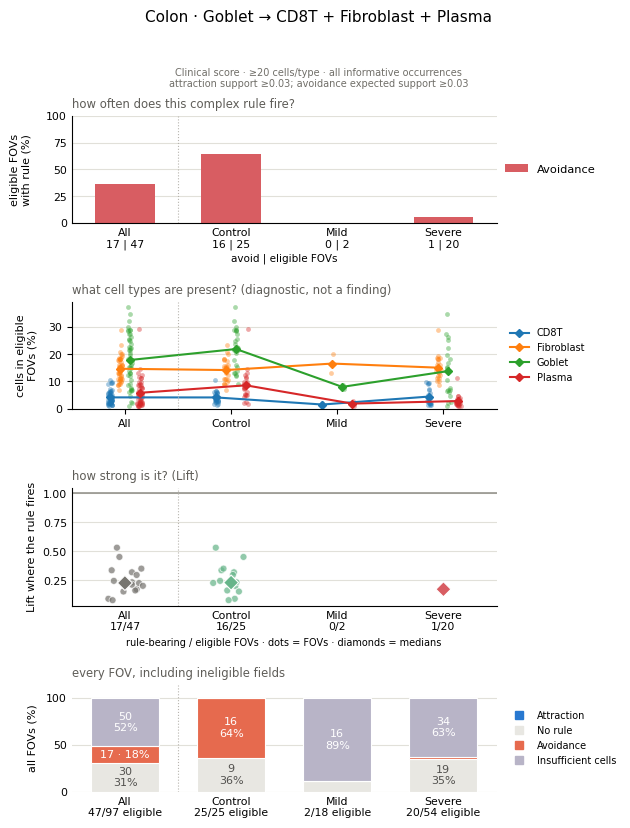

In [6]:
show_selected(0)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_001_Colon_9b234de457_summary.pdf


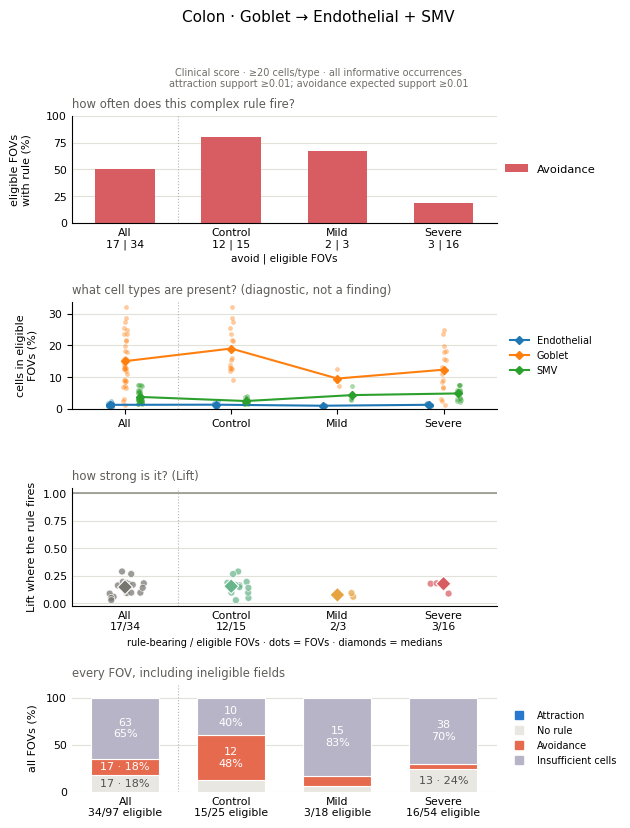

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_003_Colon_9b234de457_summary.pdf


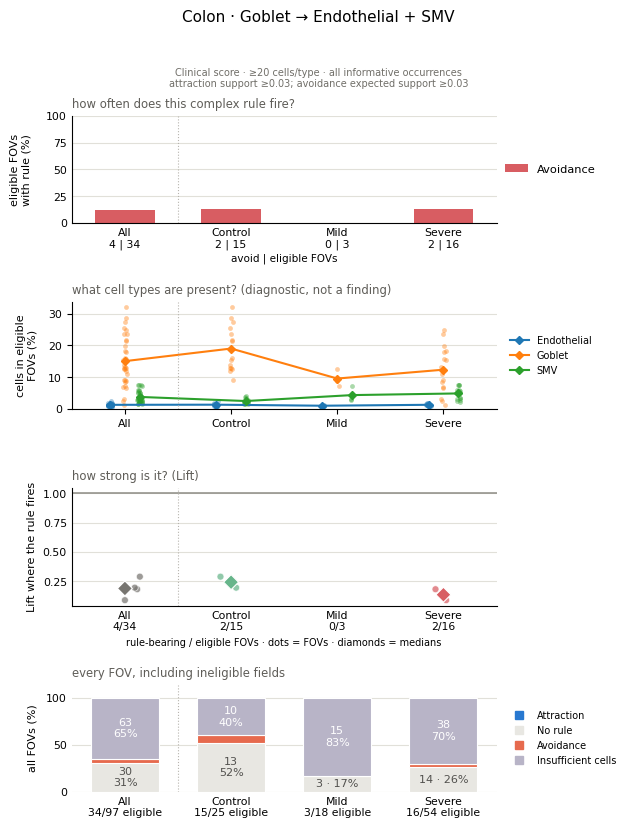

In [7]:
show_selected(1)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_001_Duodenum_7f53b8184b_summary.pdf


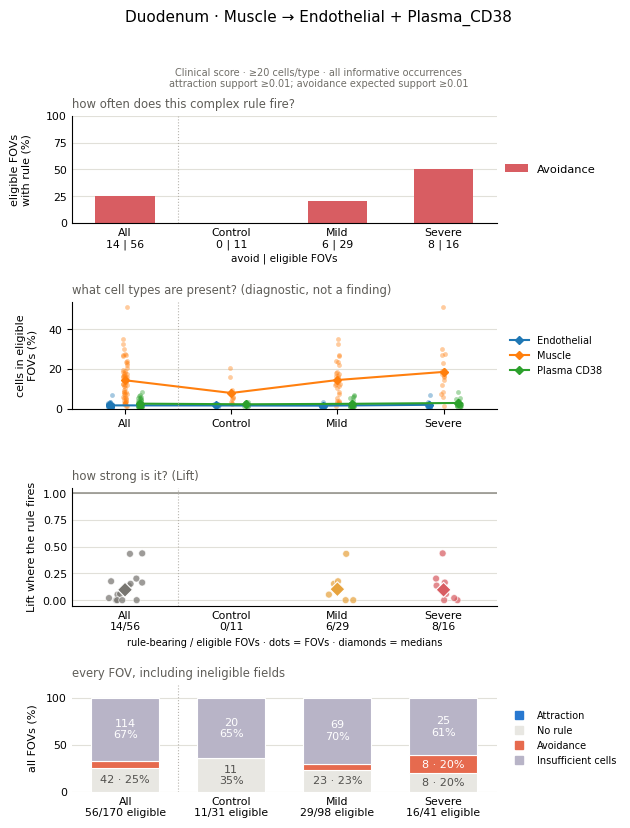

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_003_Duodenum_7f53b8184b_summary.pdf


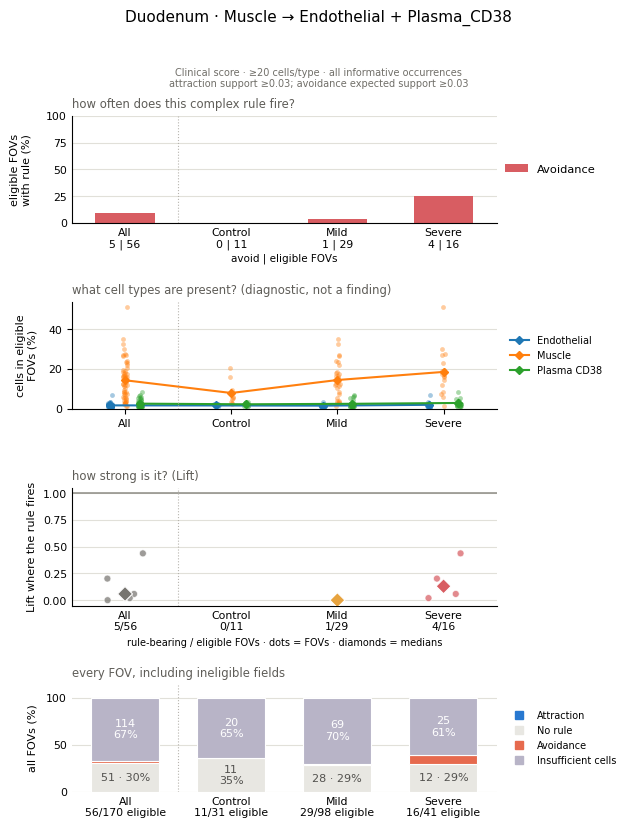

In [8]:
show_selected(2)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_001_Duodenum_bdf167def3_summary.pdf


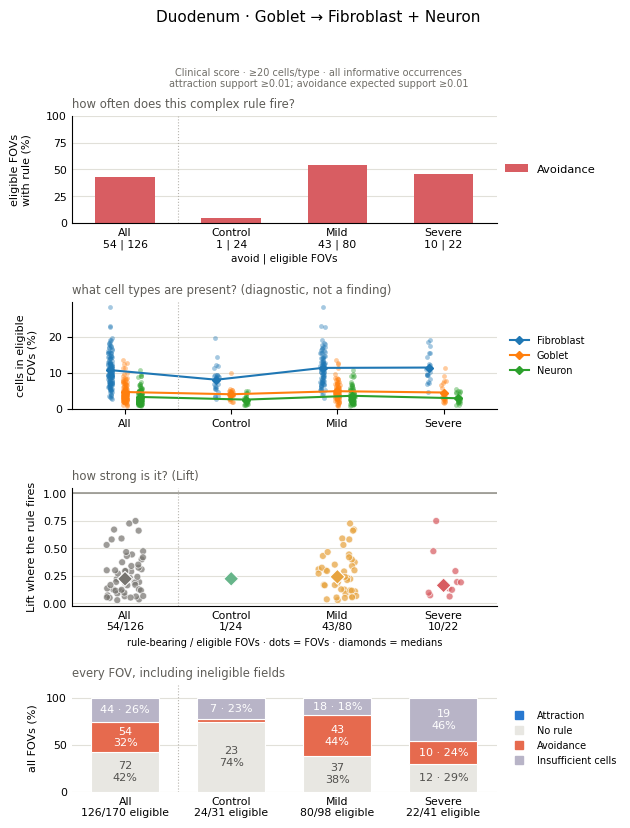

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_003_Duodenum_bdf167def3_summary.pdf


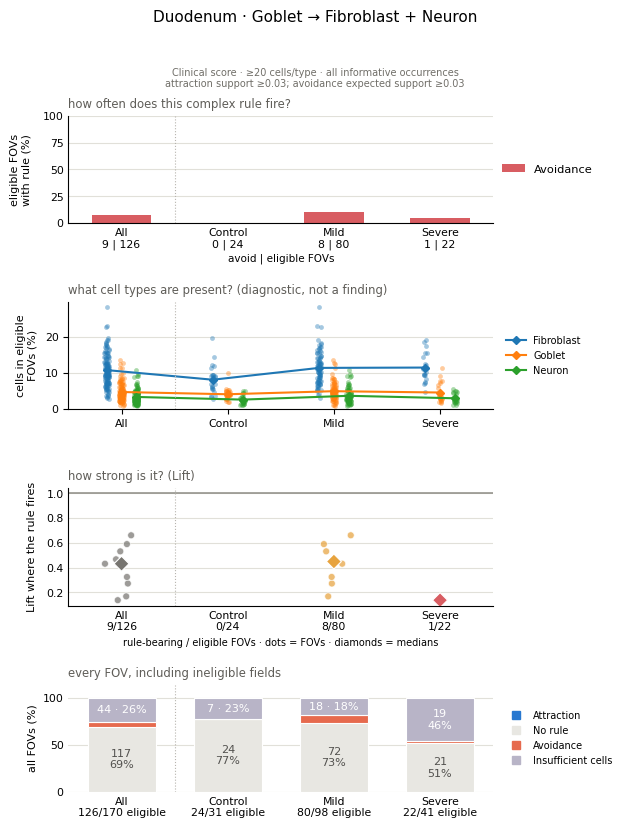

In [9]:
show_selected(3)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_001_Colon_25e4adecf2_summary.pdf


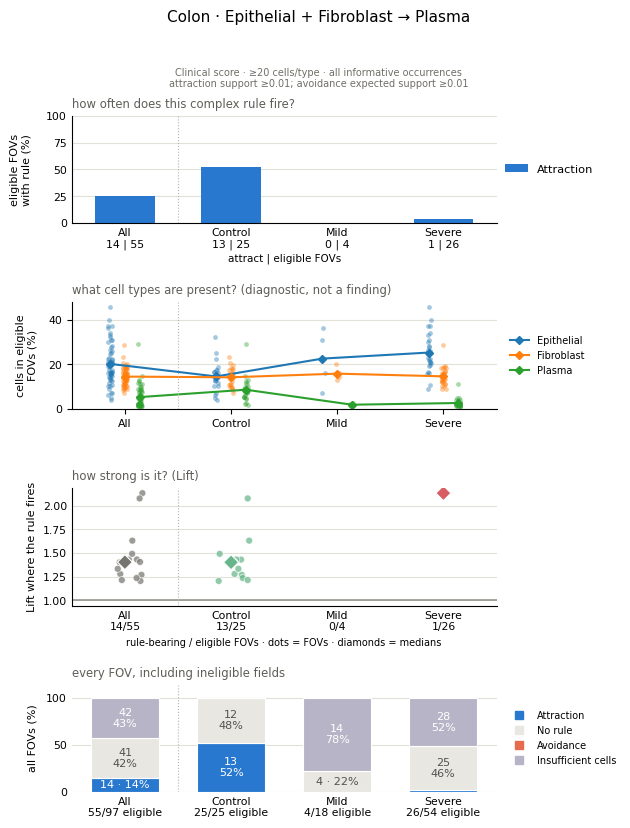

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_003_Colon_25e4adecf2_summary.pdf


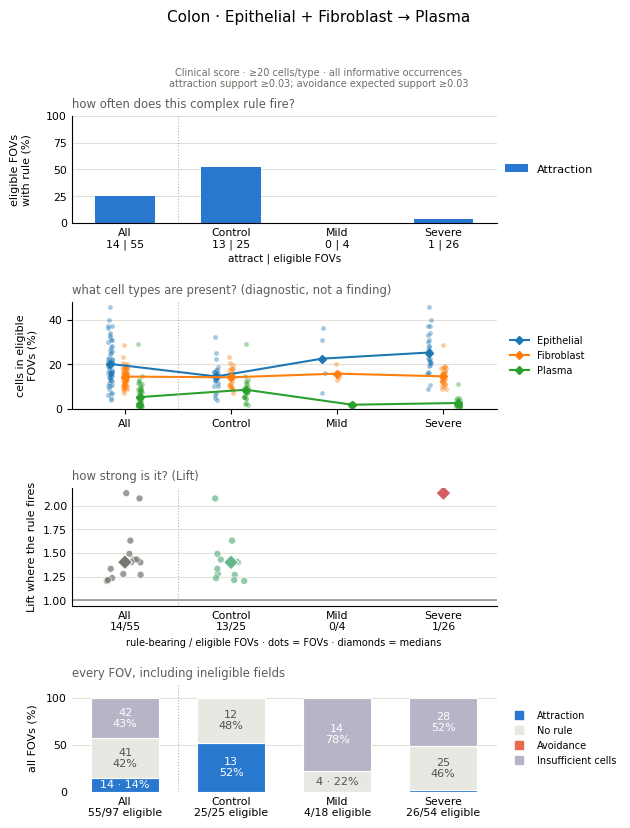

In [10]:
show_selected(4)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_001_Colon_ed6438e496_summary.pdf


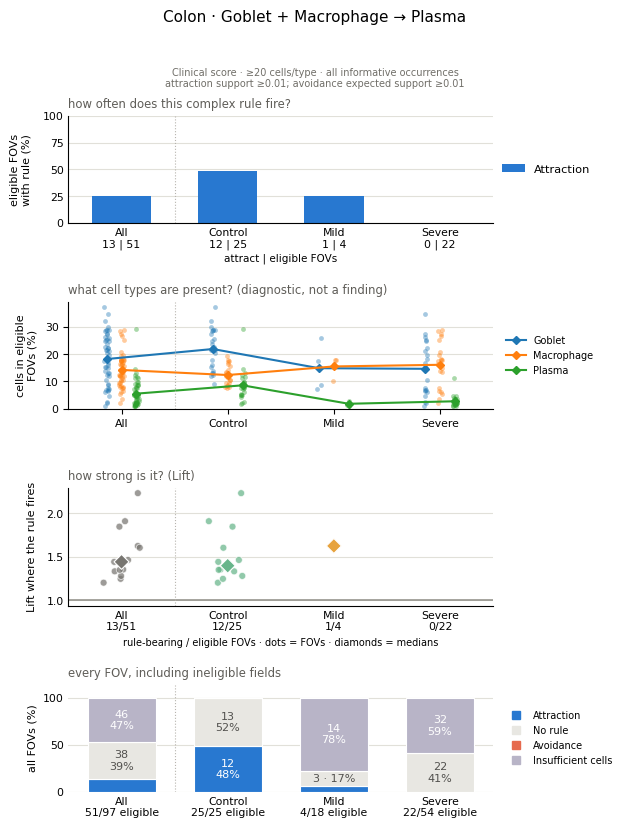

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_003_Colon_ed6438e496_summary.pdf


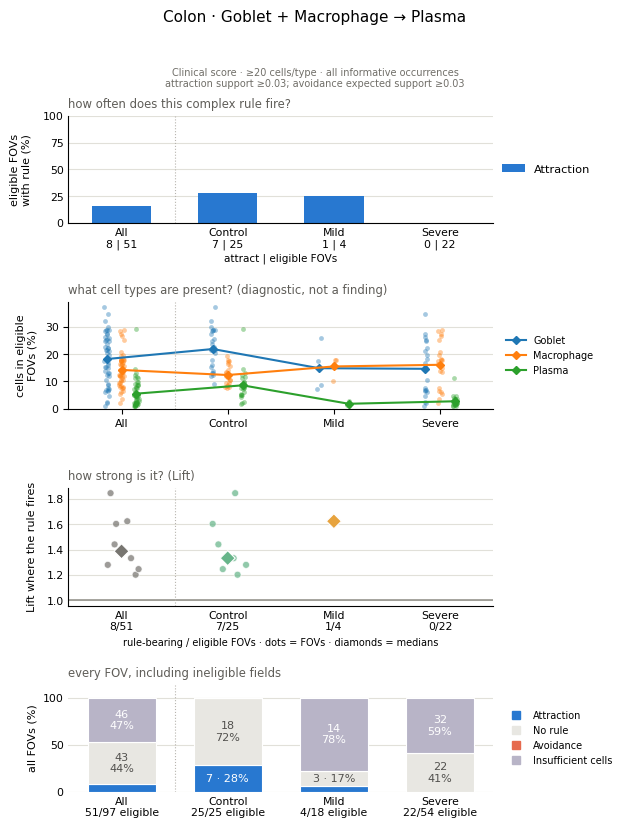

In [11]:
show_selected(5)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_001_Duodenum_ec81592ecb_summary.pdf


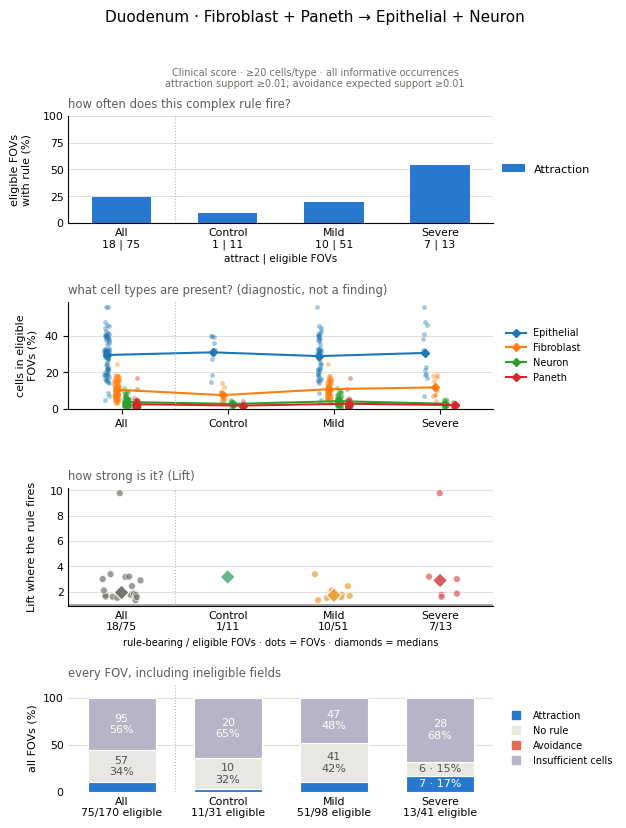

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_003_Duodenum_ec81592ecb_summary.pdf


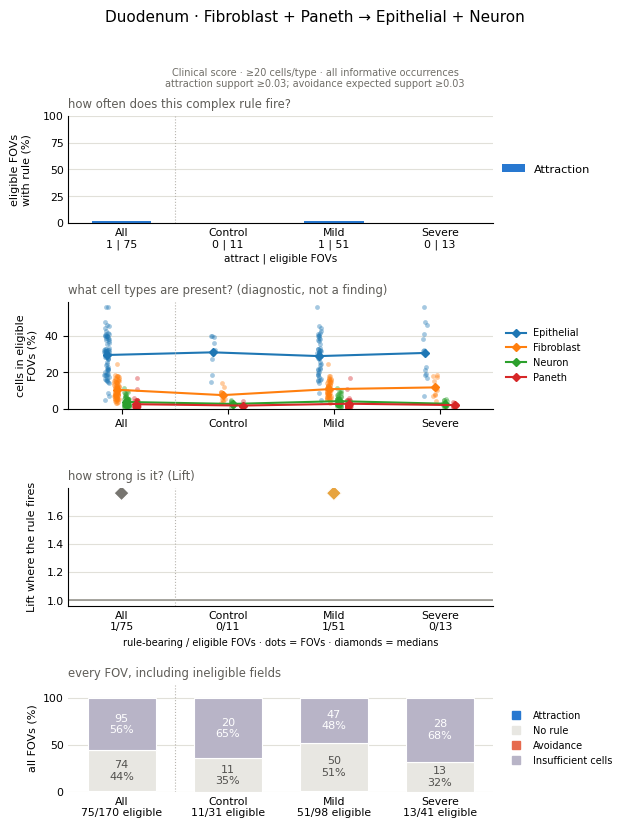

In [12]:
show_selected(6)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_001_Duodenum_d0d8022236_summary.pdf


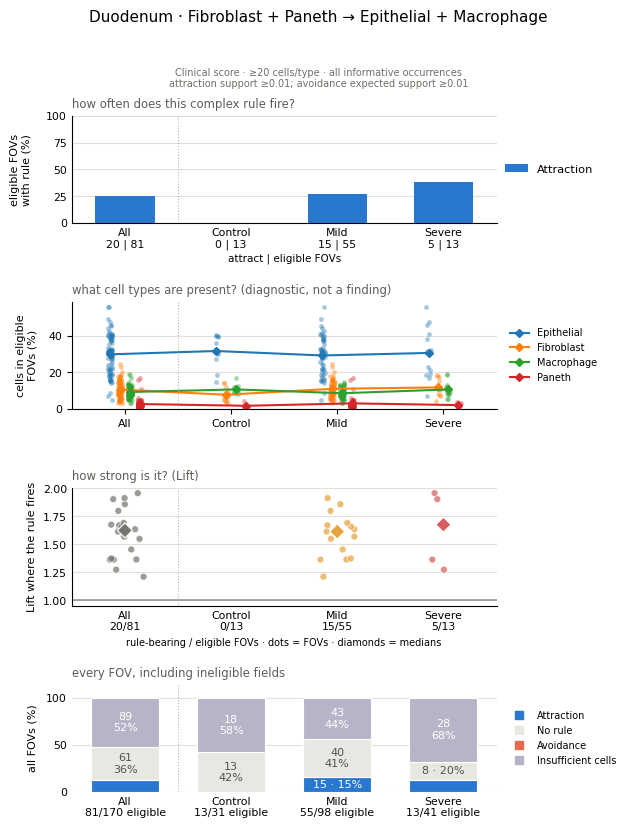

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_003_Duodenum_d0d8022236_summary.pdf


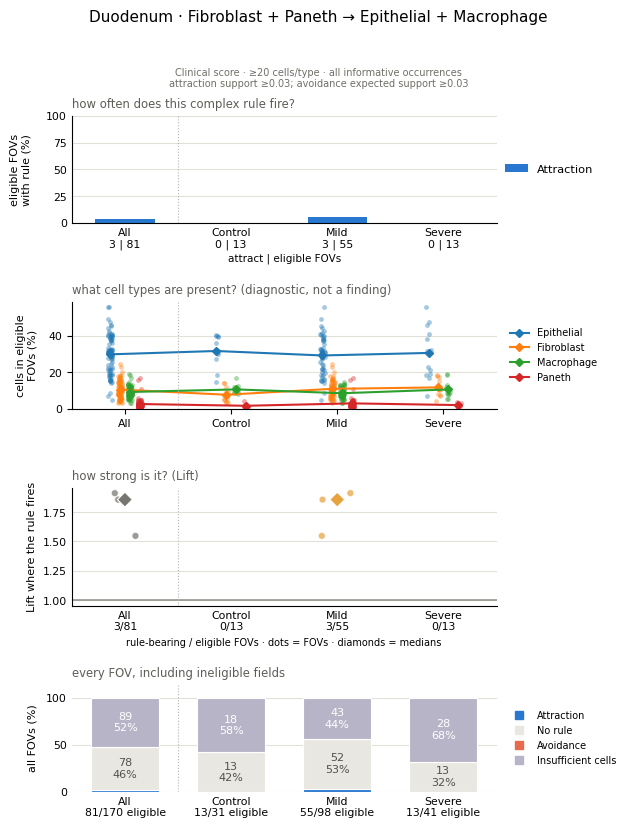

In [13]:
show_selected(7)

In [14]:
show_selected(8)

No comparison at this index.


In [15]:
show_selected(9)

No comparison at this index.


In [16]:
show_selected(10)

No comparison at this index.


In [17]:
show_selected(11)

No comparison at this index.


In [18]:
show_selected(12)

No comparison at this index.


In [19]:
show_selected(13)

No comparison at this index.


In [20]:
show_selected(14)

No comparison at this index.


In [21]:
show_selected(15)

No comparison at this index.


In [22]:
show_selected(16)

No comparison at this index.


In [23]:
show_selected(17)

No comparison at this index.


In [24]:
show_selected(18)

No comparison at this index.


In [25]:
show_selected(19)

No comparison at this index.


In [26]:
show_selected(20)

No comparison at this index.


In [27]:
show_selected(21)

No comparison at this index.


In [28]:
show_selected(22)

No comparison at this index.


In [29]:
show_selected(23)

No comparison at this index.


In [30]:
show_selected(24)

No comparison at this index.


In [31]:
show_selected(25)

No comparison at this index.


In [32]:
show_selected(26)

No comparison at this index.


In [33]:
show_selected(27)

No comparison at this index.


In [34]:
show_selected(28)

No comparison at this index.


In [35]:
show_selected(29)

No comparison at this index.


In [36]:
show_selected(30)

No comparison at this index.


In [37]:
show_selected(31)

No comparison at this index.
